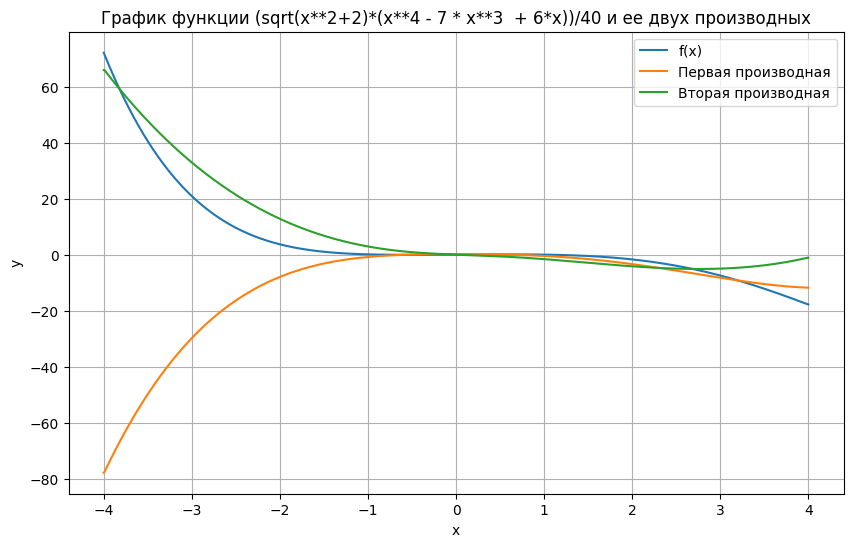

In [1]:
import matplotlib.pyplot as plt
import math
import numpy as np

def f(x):
    return (math.sqrt(x**2+2)*(x**4 - 7 * x**3  + 6*x))/40

def fFirst(x0, x1):
    return (f(x1)-f(x0))/(2*h)

def fSecond(x0, x1, x2):
    return (f(x2)-2*f(x1)+f(x0))/(h**2)

a, b = -4, 4

N = 1000 + 1

h = ( b - a ) / ( N - 1)

X = [a+i*h for i in range(N)]

F = [f(x) for x in X]

FFirst = [fFirst(X[i-1], X[i+1]) for i in range(1, len(X)-1)]
FFirst = [(f(X[1]) - f(X[0]))/h] + FFirst + [(f(X[-1]) - f(X[-2]))/h]

FSecond = [fSecond(X[i-1], X[i], X[i+1]) for i in range(1, len(X)-1)]
FSecond = [( f(X[2]) - 2 * f(X[1]) + f(X[0]) )/(h**2)] + FSecond + [
        (f(X[-1]) - 2 * f(X[-2]) + f(X[-3]))/(h**2)
    ]

plt.figure(figsize=(10, 6))
plt.plot(X, F, label='f(x)')
plt.plot(X, FFirst, label='Первая производная')
plt.plot(X, FSecond, label='Вторая производная')
plt.title('График функции (sqrt(x**2+2)*(x**4 - 7 * x**3  + 6*x))/40 и ее двух производных')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

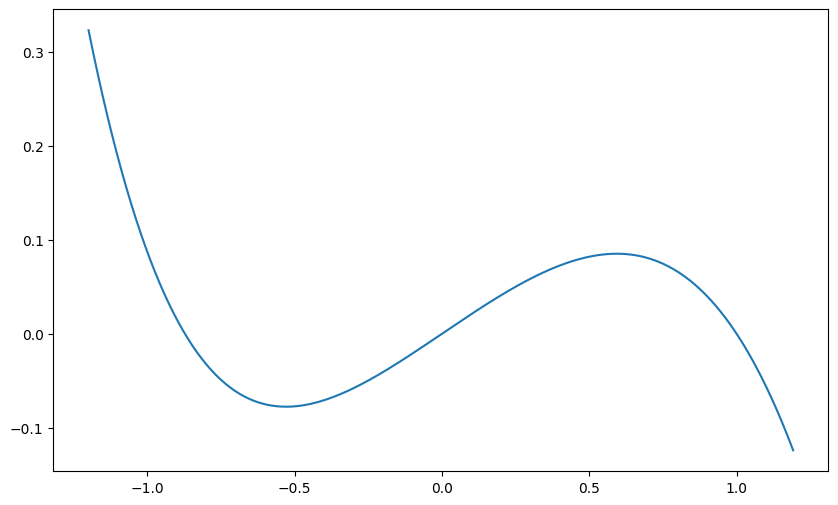

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(X[500-150:650], F[500-150:650], label='f(x)')

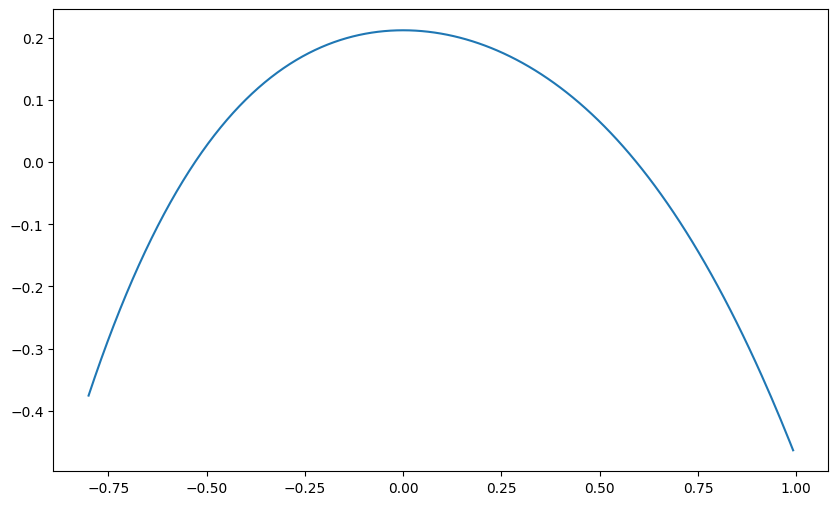

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(X[500-100:625], FFirst[500-100:625], label='f(x)')

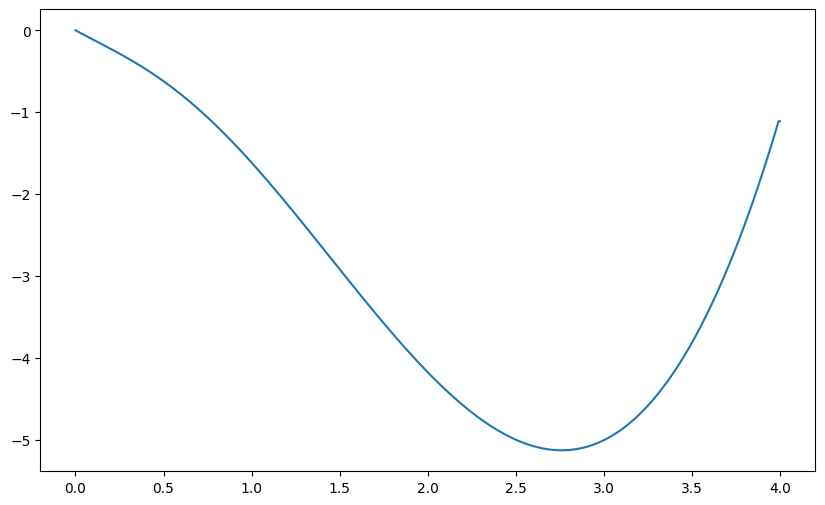

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(X[500:], FSecond[500:], label='Вторая производная')

1) Функиция непрерывна на всем интервале от [-4, 4], на графике отсутствуют разрывы, скачки, разлеты значений;
2) Корни значений функции: x_1=0, x_2=1, x_3=-0.8729833;
3) Функция убывает от [-4, -0.528) и на интервале от (0.6; 4] и возрастает на интервале от [-0.528; 0.6];
4) На графике наблюдается 2 стационарные токи, в которых достигаются локальные экстремумы: точка локального минимума x_1 = -0.528 и точка локального максимума x_2 = 0.6;
4.1) Горизонтальные касательные x_1 = -0.5 x_2 = 0.5;
5) Функция вогнута на интервале [-4; 0] и выпукла на интeрвале от [0; 4]
6) Функция имеет точку перегиба в точке 0
7) Функция определена на всем интервале без ограничений;
8) Функция не является переодической;
9) Анализ на бесконечности невозможен, потому что интервал ограничен

# 13.2

In [ ]:
from scipy.optimize import bisect

root_arr = []

bisect_tol = 1e-7

root_1 = round(bisect(f, -4, -0.528, xtol=bisect_tol), 7)
root_2 = round(bisect(f, 0.6, 4, xtol=bisect_tol), 7)
root_3 = round(bisect(f, -0.528, 0.6, xtol=bisect_tol), 7)

print(root_1, root_2, root_3)

(-0.8729833, 1.0, 0.0)

# 13.3

In [54]:
from scipy.optimize import fmin

min_arr = []
max_arr  = []

for i in [root_1, root_2, root_3]:
    min = fmin(f, i, xtol=bisect_tol)[0]
    max = fmin(lambda x: -f(x), i, xtol=bisect_tol)[0]
    
    if min>=a and min<=b:
        min_arr.append(min.round(7))
    if max>=a and max<=b:
        max_arr.append(max.round(7))

min_values = list(set(min_arr))
max_values = list(set(max_arr))


Optimization terminated successfully.
         Current function value: -0.077739
         Iterations: 24
         Function evaluations: 48
Optimization terminated successfully.
         Current function value: -30.746194
         Iterations: 31
         Function evaluations: 62
Optimization terminated successfully.
         Current function value: -0.085185
         Iterations: 25
         Function evaluations: 50
Optimization terminated successfully.
         Current function value: -0.077739
         Iterations: 33
         Function evaluations: 66
Optimization terminated successfully.
         Current function value: -0.085185
         Iterations: 33
         Function evaluations: 66


C:\Users\raven\AppData\Local\Temp\ipykernel_41404\3282891766.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return (math.sqrt(x**2+2)*(x**4 - 7 * x**3  + 6*x))/40
C:\Users\raven\AppData\Local\Temp\ipykernel_41404\2496220803.py:8: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  max = fmin(lambda x: -f(x), i, xtol=bisect_tol)[0]


In [55]:
print(min_values)
print(max_values)

[-0.5293619]
[0.5934849]


# 13.4

In [67]:
import math

a, b = -4, 4

h = 1e-5

N = math.floor((b - a) / h) + 1

X = [a+i*h for i in range(N)]

FSecond = [fSecond(X[i-1], X[i], X[i+1]) for i in range(1, len(X)-1)]
FSecond = [( f(X[2]) - 2 * f(X[1]) + f(X[0]) )/(h**2)] + FSecond + [
        (f(X[-1]) - 2 * f(X[-2]) + f(X[-3]))/(h**2)
    ]

R = [(X[i] + X[i+1])/2 for i in range(len(FSecond)-1) if FSecond[i]*FSecond[i+1]<0]

In [ ]:
R

[5.000000000254801e-06]